# DIF-PI ablation notebook

This notebook runs module-level and mechanism-level ablations for the integrated DIF-PI workflow.

## Input
- processed transactional export from `eda-complete-journey.ipynb`
- daily SKU panel used by `dif-pi.ipynb`
- saved *TRAIN_SKUs* / *TEST_SKUs* split when available
- saved global forecaster artifact when available
- Python modules:
  - `tbwisa.py`
  - `loglinear_scenarios.py`
  - `xgboost_scenarios.py`
  - `npd.py`
  - `sdg.py`

## Output
- `ablation_summary.csv`
- `ablation_case_level_results.csv`
- `tbwisa_mechanism_ablation_summary.csv`
- `managerial_ablation_summary.csv`
- `decision_score_change_under_ablations.png`
- `uplift_change_under_ablations.png`
- `screening_status_distribution_under_ablations.png`
- `recommended_delta_shift_under_ablations.png`
- `window_shift_under_ablations.png`

## 1) Environment and ablation configuration

In [3]:
from pathlib import Path
import json
import math
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    from xgboost import XGBRegressor
    _xgb_ok = True
except Exception:
    _xgb_ok = False

import sys
sys.path.insert(0, str(Path('.').resolve()))

from src.tbwisa import TBWISAGenerator
from src.loglinear_scenarios import LogLinearScenarioGeneration
from src.xgboost_scenarios import XGBoostScenarioGeneration
from src.npd import NPDModel
from src.sdg import compute_difpi_sku_split

warnings.filterwarnings("ignore")

REPO_ROOT = Path(".").resolve()
TX_PATH = REPO_ROOT / "datasets" / "processed" / "difpi_transactions.csv"
PANEL_PATH = REPO_ROOT / "datasets" / "processed" / "difpi_pricing_demand_panel.csv"
GLOBAL_FORECASTER_DIR = REPO_ROOT / "artifacts" / "models" / "scenario_gen_transformer_global"
TEST_SKU_PATH = REPO_ROOT / "artifacts" / "difpi_exec_demo" / "test_skus.csv"
OUT_DIR = REPO_ROOT / "artifacts" / "difpi_exec_demo"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CASE_SKUS = ["1082185", "9553031", "908531"]
HORIZON = 30
MIN_WINDOW = 7
MAX_WINDOW = 14
LENGTH_PENALTY = 0.0
SEED = 42
DELTAS_PCT = [-15, -10, -5, -2, 0, 2, 5, 10, 15]

TIME_COL = "date"
SKU_COL = "StockCode"
PRICE_COL = "price"
DEMAND_COL = "demand"
CUST_COL = "CustomerID"
DATE_COL = "InvoiceDate"

# NPD settings
NPD_K = 5
NPD_MIN_EVENTS = 7
NPD_HORIZON = HORIZON
NPD_CLUSTER_COUNT = 4

# Controlled elasticity settings
CONTROLLED_ELAST_KW = dict(
    seasonal_periods=(7.0, 365.25),
    eps=1e-9,
    prior_eps=0.05,
    use_event=True,
    price_change_pct_thresh=0.01,
    elast_max_abs=4.0,
    huber_epsilon=1.35,
    huber_alpha=1e-4,
    min_fit_rows=30,
)

ABLATION_REGISTRY = [
    {
        "ablation_name": "full_dif_pi_reference",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "sdg_off",
        "sdg_enabled": False,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "clustering_off",
        "sdg_enabled": True,
        "clustered_npd_enabled": False,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "npd_timing_weight_off",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": False,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "controlled_elasticity_to_simple_loglog",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": False,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "nonlinear_elasticity_off",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": False,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "stochastic_simulation_off",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": False,
        "screening_enabled": True,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "x_tbwisa_screening_off",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": False,
        "forecaster_backend": "global_transformer",
    },
    {
        "ablation_name": "forecaster_replacement_arima",
        "sdg_enabled": True,
        "clustered_npd_enabled": True,
        "npd_timing_enabled": True,
        "controlled_elasticity_enabled": True,
        "nonlinear_elasticity_enabled": True,
        "stochastic_simulation_enabled": True,
        "screening_enabled": True,
        "forecaster_backend": "arima",
    },
]
pd.DataFrame(ABLATION_REGISTRY)

,ablation_name,sdg_enabled,clustered_npd_enabled,npd_timing_enabled,controlled_elasticity_enabled,nonlinear_elasticity_enabled,stochastic_simulation_enabled,screening_enabled,forecaster_backend
0,full_dif_pi_reference,True,True,True,True,True,True,True,global_transformer
1,sdg_off,False,True,True,True,True,True,True,global_transformer
2,clustering_off,True,False,True,True,True,True,True,global_transformer
3,npd_timing_weight_off,True,True,False,True,True,True,True,global_transformer
4,controlled_elasticity_to_simple_loglog,True,True,True,False,True,True,True,global_transformer
5,nonlinear_elasticity_off,True,True,True,True,False,True,True,global_transformer
6,stochastic_simulation_off,True,True,True,True,True,False,True,global_transformer
7,x_tbwisa_screening_off,True,True,True,True,True,True,False,global_transformer
8,forecaster_replacement_arima,True,True,True,True,True,True,True,arima


## 2) Data loading

In [4]:
def _detect_first_column(df, candidates, label):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Could not find {label} column. Tried: {candidates}. Available columns: {list(df.columns)}")

if not TX_PATH.exists():
    raise FileNotFoundError(f"Missing processed transaction file: {TX_PATH}")
if not PANEL_PATH.exists():
    raise FileNotFoundError(f"Missing panel file: {PANEL_PATH}")

tx = pd.read_csv(TX_PATH)
panel = pd.read_csv(PANEL_PATH)

# Robust column detection so the notebook can reuse the same DIF-PI exports
# even when the panel uses 'timestamp' or another date-like name instead of 'date'.
DATE_COL = _detect_first_column(tx, [DATE_COL, "InvoiceDate", "date", "timestamp", "Datetime", "Date"], "transaction date")
TIME_COL = _detect_first_column(panel, [TIME_COL, "timestamp", "date", "InvoiceDate", "Datetime", "Date"], "panel time")
SKU_COL = _detect_first_column(panel, [SKU_COL, "StockCode", "sku", "SKU"], "panel SKU")
PRICE_COL = _detect_first_column(panel, [PRICE_COL, "price", "Price", "unit_price", "UnitPrice"], "panel price")
DEMAND_COL = _detect_first_column(panel, [DEMAND_COL, "demand", "Demand", "quantity", "Quantity"], "panel demand")
if CUST_COL not in tx.columns and "customer_id" in tx.columns:
    CUST_COL = "customer_id"

if DATE_COL in tx.columns:
    tx[DATE_COL] = pd.to_datetime(tx[DATE_COL])
if TIME_COL in panel.columns:
    panel[TIME_COL] = pd.to_datetime(panel[TIME_COL])

for c in [SKU_COL]:
    if c in tx.columns:
        tx[c] = tx[c].astype(str)
    if c in panel.columns:
        panel[c] = panel[c].astype(str)

print("TX:", TX_PATH)
print("PANEL:", PANEL_PATH)
print("Resolved DATE_COL:", DATE_COL)
print("Resolved TIME_COL:", TIME_COL)
print("Resolved SKU_COL:", SKU_COL)
print("Resolved PRICE_COL:", PRICE_COL)
print("Resolved DEMAND_COL:", DEMAND_COL)
print("TX shape:", tx.shape)
print("PANEL shape:", panel.shape)
display(tx.head())
display(panel.head())

TX: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_transactions.csv
PANEL: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/datasets/processed/difpi_pricing_demand_panel.csv
Resolved DATE_COL: InvoiceDate
Resolved TIME_COL: timestamp
Resolved SKU_COL: StockCode
Resolved PRICE_COL: price
Resolved DEMAND_COL: demand
TX shape: (2576815, 5)
PANEL shape: (209633, 4)


,CustomerID,InvoiceDate,StockCode,Quantity,UnitPrice
0,2375,2018-01-02,1004906,1,1.39
1,2375,2018-01-02,1033142,1,0.82
2,2375,2018-01-02,1036325,1,0.99
3,2375,2018-01-02,1082185,1,1.21
4,2375,2018-01-02,8160430,1,1.50


,timestamp,StockCode,price,demand
0,2018-01-13,6534178,0.002191,2456.0
1,2018-01-14,6534178,0.002070,2416.0
2,2018-01-15,6534178,0.002199,2728.0
3,2018-01-16,6534178,0.002289,8737.0
4,2018-01-17,6534178,0.002289,0.0


## 3) Held-out SKU split and case-SKU checks

In [5]:
def load_test_skus():
    if not TEST_SKU_PATH.exists():
        raise FileNotFoundError(f"Missing test SKU split file: {TEST_SKU_PATH}")
    df = pd.read_csv(TEST_SKU_PATH)
    if SKU_COL in df.columns:
        return sorted(df[SKU_COL].astype(str).unique().tolist()), TEST_SKU_PATH
    if "test_sku" in df.columns:
        return sorted(df["test_sku"].astype(str).unique().tolist()), TEST_SKU_PATH
    raise KeyError(f"Could not find SKU column in test SKU file: {TEST_SKU_PATH}")

TEST_SKUS, TEST_SKU_PATH = load_test_skus()
print("Loaded TEST_SKUs from:", TEST_SKU_PATH if TEST_SKU_PATH else "recomputed split")
print("Number of held-out TEST_SKUs:", len(TEST_SKUS))

case_sku_check = pd.DataFrame({"case_sku": CASE_SKUS})
case_sku_check["in_test_split"] = case_sku_check["case_sku"].isin(TEST_SKUS)
display(case_sku_check)

Loaded TEST_SKUs from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/difpi_exec_demo/test_skus.csv
Number of held-out TEST_SKUs: 60


,case_sku,in_test_split
0,1082185,True
1,9553031,True
2,908531,True


## 4) Helpers for NPD timing, sparse-history support, forecasting, scenario generation, and screening

In [6]:
class ARIMAForecaster:
    def __init__(self, order=(1, 1, 1)):
        self.order = order

    def forecast(self, history, horizon):
        history = np.asarray(history, dtype=float)
        if len(history) < 10:
            return np.repeat(history[-1] if len(history) else 0.0, horizon)
        try:
            res = SARIMAX(
                history,
                order=self.order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            return np.asarray(res.forecast(steps=horizon))
        except Exception:
            return np.repeat(history[-1], horizon)

def revenue(price, demand):
    return np.asarray(price, float) * np.asarray(demand, float)

def choose_best_window(rev, min_len=MIN_WINDOW, max_len=MAX_WINDOW, length_penalty=LENGTH_PENALTY):
    return TBWISAGenerator.best_window(np.asarray(rev, float), min_len=min_len, max_len=max_len, length_penalty=length_penalty)

def build_case_series(case_sku):
    sku_df = panel[panel[SKU_COL].astype(str) == str(case_sku)].copy()
    sku_df = sku_df.sort_values(TIME_COL).set_index(TIME_COL)
    full = pd.date_range(sku_df.index.min(), sku_df.index.max(), freq="D")
    sku_df = sku_df.reindex(full)
    sku_df.index.name = TIME_COL
    sku_df[PRICE_COL] = sku_df[PRICE_COL].ffill()
    sku_df[DEMAND_COL] = sku_df[DEMAND_COL].fillna(0.0)
    sku_df = sku_df.reset_index()
    decision_date = sku_df[TIME_COL].max() - pd.Timedelta(days=HORIZON)
    train_df = sku_df[sku_df[TIME_COL] <= decision_date].copy()
    test_df = sku_df[sku_df[TIME_COL] > decision_date].copy()
    return sku_df, train_df, test_df, decision_date

def moving_block_bootstrap_support(y, block=7, out_len=None, random_state=SEED):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y, float)
    if out_len is None:
        out_len = len(y)
    if len(y) <= block:
        return y.copy()
    starts = np.arange(0, max(1, len(y) - block + 1))
    out = []
    while len(out) < out_len:
        s = int(rng.choice(starts))
        out.extend(y[s:s+block].tolist())
    return np.asarray(out[:out_len], float)

def apply_sdg_support_if_enabled(train_df, enabled=True):
    out = train_df.copy()
    if not enabled:
        return out
    y = out[DEMAND_COL].astype(float).values
    zero_share = float(np.mean(y <= 1e-12))
    if zero_share < 0.60:
        return out
    # conservative support path for sparse histories:
    # replace very long zero runs with moving-block-bootstrap values from active blocks
    y_syn = moving_block_bootstrap_support(y, block=7, out_len=len(y), random_state=SEED)
    repaired = y.copy()
    run_start = None
    for i, v in enumerate(y):
        if v <= 1e-12 and run_start is None:
            run_start = i
        if (v > 1e-12 or i == len(y)-1) and run_start is not None:
            run_end = i if v > 1e-12 else i+1
            if (run_end - run_start) >= 7:
                repaired[run_start:run_end] = np.maximum(0.0, y_syn[run_start:run_end])
            run_start = None
    out[DEMAND_COL] = repaired
    return out

def build_customer_gap_features(tx_df):
    rows = []
    for cust, g in tx_df[[CUST_COL, DATE_COL]].dropna().sort_values([CUST_COL, DATE_COL]).groupby(CUST_COL):
        d = g[DATE_COL].values
        if len(d) < max(NPD_MIN_EVENTS, NPD_K + 2):
            continue
        gaps = np.diff(d).astype("timedelta64[D]").astype(int)
        if len(gaps) < NPD_K + 1:
            continue
        rows.append({
            CUST_COL: cust,
            "frequency": len(d),
            "mean_gap": float(np.mean(gaps)),
            "std_gap": float(np.std(gaps)),
            "cv_gap": float(np.std(gaps) / (np.mean(gaps) + 1e-9)),
            "last_gap": float(gaps[-1]),
        })
    return pd.DataFrame(rows)

def fit_quick_npd_models(tx_df, clustered=True):
    npd_util = NPDModel(k=NPD_K, min_events=NPD_MIN_EVENTS, horizon=NPD_HORIZON)
    X, y = npd_util.make_supervised(tx_df, cust_col=CUST_COL, date_col=DATE_COL)
    if _xgb_ok:
        base_model = XGBRegressor(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=4,
        )
    else:
        base_model = RandomForestRegressor(n_estimators=300, random_state=SEED)

    if not clustered:
        base_model.fit(X, y)
        yhat = np.asarray(base_model.predict(X), float)
        mae = float(mean_absolute_error(y, yhat))
        return {"global": base_model}, None, mae

    cust_meta = build_customer_gap_features(tx_df)
    if len(cust_meta) < NPD_CLUSTER_COUNT:
        base_model.fit(X, y)
        yhat = np.asarray(base_model.predict(X), float)
        mae = float(mean_absolute_error(y, yhat))
        return {"global": base_model}, None, mae

    feat_cols = ["frequency", "mean_gap", "std_gap", "cv_gap", "last_gap"]
    scaler = StandardScaler()
    Z = scaler.fit_transform(cust_meta[feat_cols].values)
    kmeans = KMeans(n_clusters=min(NPD_CLUSTER_COUNT, len(cust_meta)), random_state=SEED, n_init=10)
    cust_meta["cluster"] = kmeans.fit_predict(Z)

    cluster_models = {}
    # build gap windows by customer, then assign windows to clusters
    tmp = tx_df[[CUST_COL, DATE_COL]].dropna().sort_values([CUST_COL, DATE_COL])
    windows = []
    targets = []
    clusters = []
    cluster_lookup = cust_meta.set_index(CUST_COL)["cluster"].to_dict()
    for cust, g in tmp.groupby(CUST_COL):
        if cust not in cluster_lookup:
            continue
        d = g[DATE_COL].values
        if len(d) < NPD_MIN_EVENTS:
            continue
        gaps = np.diff(d).astype("timedelta64[D]").astype(int)
        for i in range(NPD_K, len(gaps)):
            windows.append(gaps[i-NPD_K:i])
            targets.append(gaps[i])
            clusters.append(cluster_lookup[cust])

    windows = np.asarray(windows, float)
    targets = np.asarray(targets, float)
    clusters = np.asarray(clusters, int)

    for cl in np.unique(clusters):
        mask = clusters == cl
        model = XGBRegressor(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=4,
        ) if _xgb_ok else RandomForestRegressor(n_estimators=250, random_state=SEED)
        model.fit(windows[mask], targets[mask])
        cluster_models[int(cl)] = model

    def _cluster_model_predict(X_in):
        # fallback to global median cluster if needed
        preds = []
        fallback_cluster = int(cust_meta["cluster"].mode().iloc[0])
        model = cluster_models[fallback_cluster]
        for row in np.asarray(X_in, float):
            preds.append(float(model.predict(np.asarray(row, float).reshape(1, -1))[0]))
        return np.asarray(preds, float)

    class ClusterWrapper:
        input_length = NPD_K
        def predict(self, X_in):
            return _cluster_model_predict(X_in)

    wrapped = ClusterWrapper()
    yhat = wrapped.predict(X)
    mae = float(mean_absolute_error(y, yhat))
    return {"clustered": wrapped}, {"cust_meta": cust_meta, "kmeans": kmeans, "scaler": scaler}, mae

def compute_intention_weight(tx_df, clustered=True, timing_on=True):
    future_index = pd.date_range(
        tx_df[DATE_COL].max().normalize() + pd.Timedelta(days=1),
        periods=NPD_HORIZON,
        freq="D",
    )
    neutral_idx = pd.Series(0.0, index=future_index)
    if not timing_on:
        return neutral_idx, 0.0, np.nan

    npd_util = NPDModel(k=NPD_K, min_events=NPD_MIN_EVENTS, horizon=NPD_HORIZON)
    models, cluster_meta, mae = fit_quick_npd_models(tx_df, clustered=clustered)
    model = list(models.values())[0]
    _, idx = npd_util.intention_index(
        tx_df, model, cust_col=CUST_COL, date_col=DATE_COL, horizon=NPD_HORIZON
    )
    idx = pd.Series(idx, index=getattr(idx, "index", future_index))
    idx = idx.reindex(future_index).fillna(0.0)

    alpha = float(npd_util.alpha_from_mae(mae))
    alpha = max(alpha, 0.0)
    return idx, alpha, mae

def try_load_transformer_forecaster():
    Loader = None
    load_errors = []

    # use the same import style as dif-pi first
    try:
        from src.transformer_forecaster import ScenarioGenerationTransformerForecaster as Loader
    except Exception as e:
        load_errors.append(f"src.transformer_forecaster import failed: {e}")

    if Loader is None:
        try:
            from transformer_forecaster import ScenarioGenerationTransformerForecaster as Loader
        except Exception as e:
            load_errors.append(f"transformer_forecaster import failed: {e}")

    if Loader is None:
        return None, None, load_errors

    model_dir = Path(GLOBAL_FORECASTER_DIR)
    if not ((model_dir / "scenario_gen_transformer_config.json").exists() and (model_dir / "scenario_gen_transformer.keras").exists()):
        load_errors.append(f"missing saved forecaster files in {model_dir}")
        return None, None, load_errors

    try:
        return Loader.load(model_dir), model_dir, load_errors
    except Exception as e:
        load_errors.append(f"load failed from {model_dir}: {e}")
        return None, None, load_errors

GLOBAL_FORECASTER, GLOBAL_FORECASTER_PATH, GLOBAL_FORECASTER_LOAD_ERRORS = try_load_transformer_forecaster()
print("Global Transformer forecaster loaded:", GLOBAL_FORECASTER is not None)
if GLOBAL_FORECASTER_PATH is not None:
    print("Loaded global forecaster from:", GLOBAL_FORECASTER_PATH)
elif GLOBAL_FORECASTER_LOAD_ERRORS:
    print("Forecaster load notes:")
    for msg in GLOBAL_FORECASTER_LOAD_ERRORS[:10]:
        print(" -", msg)

def forecast_with_backend(y_hist, horizon, backend="global_transformer"):
    y_hist = np.asarray(y_hist, float)
    if backend == "global_transformer":
        if GLOBAL_FORECASTER is None:
            raise RuntimeError(
                "Global Transformer forecaster could not be loaded. "
                "Please check GLOBAL_FORECASTER_DIR before running the full reference ablation."
            )
        try:
            return np.asarray(GLOBAL_FORECASTER.forecast(y_hist, horizon), float).reshape(-1)
        except Exception as e:
            raise RuntimeError(f"Global Transformer forecast failed: {e}")
    if backend == "arima":
        return ARIMAForecaster(order=(1, 1, 1)).forecast(y_hist, horizon)
    raise ValueError(f"Unsupported forecasting backend: {backend}")


def build_timing_multiplier(intent_idx, decision_date, horizon, alpha):
    future_index = pd.date_range(
        pd.Timestamp(decision_date).normalize() + pd.Timedelta(days=1),
        periods=horizon,
        freq="D",
    )
    if intent_idx is None or alpha <= 0:
        return np.ones(horizon, dtype=float)

    idx = pd.Series(intent_idx).copy()
    if not isinstance(idx.index, pd.DatetimeIndex):
        idx.index = future_index[: len(idx)]
    idx = idx.reindex(future_index).fillna(0.0).astype(float)

    arr = idx.values
    if np.allclose(arr, arr[0]):
        centered = np.zeros_like(arr)
    else:
        centered = arr - arr.mean()
        denom = np.max(np.abs(centered)) + 1e-9
        centered = centered / denom

    mult = 1.0 + float(alpha) * centered
    mult = np.clip(mult, 0.7, 1.3)
    return mult

def build_tbwisa_variant(train_df, controlled=True, nonlinear=True, stochastic=True):
    tb = TBWISAGenerator()
    if controlled:
        tb.configure_controlled_elasticity(**CONTROLLED_ELAST_KW)
    if not nonlinear:
        tb.non_linear_elasticity = lambda change, base_elasticity: base_elasticity
    if not stochastic:
        tb.apply_randomness = lambda demand, change, randomness_factor=0.01, cap=0.05, seed=42: np.asarray(demand, float)
    return tb

def run_scenario_generators(train_df, cfg):
    train_pos = train_df[(train_df[PRICE_COL] > 0) & (train_df[DEMAND_COL] > 0)].copy()
    if len(train_pos) < 10:
        raise ValueError("Not enough positive rows to run scenario generators.")
    # Keep a datetime index for the baseline scenario generators, which build future date ranges
    if TIME_COL in train_pos.columns:
        train_pos = train_pos.sort_values(TIME_COL)
        train_pos_ts = train_pos.set_index(TIME_COL).copy()
    else:
        train_pos_ts = train_pos.copy()
    tb = build_tbwisa_variant(
        train_pos,
        controlled=cfg["controlled_elasticity_enabled"],
        nonlinear=cfg["nonlinear_elasticity_enabled"],
        stochastic=cfg["stochastic_simulation_enabled"],
    )
    p_sc, d_sc = tb.generate_scenarios(train_pos, PRICE_COL, DEMAND_COL, DELTAS_PCT)

    ll = LogLinearScenarioGeneration()
    xg = XGBoostScenarioGeneration()
    ll.train(train_pos_ts, PRICE_COL, DEMAND_COL)
    xg.train(train_pos_ts, PRICE_COL, DEMAND_COL)
    ll_p, ll_d = ll.generate_scenarios(train_pos_ts, DELTAS_PCT, forecast_length=HORIZON)
    xg_p, xg_d = xg.generate_scenarios(train_pos_ts, DELTAS_PCT, forecast_length=HORIZON)

    def _norm_keys(d):
        out = {}
        for k, v in d.items():
            if isinstance(k, str) and "%" in k:
                pct = int(str(k).split("change")[-1].replace("%", "").strip())
            else:
                pct = int(k)
            out[pct] = np.asarray(v, float)
        return out

    return {
        "tbwisa": (_norm_keys(p_sc), _norm_keys(d_sc)),
        "loglinear": (_norm_keys(ll_p), _norm_keys(ll_d)),
        "xgboost": (_norm_keys(xg_p), _norm_keys(xg_d)),
    }, getattr(tb, "_last_elasticity_meta", {})

def build_surrogate_dataset(tb_scenarios, backend, intent_alpha):
    rows = []
    p_dict, d_dict = tb_scenarios
    for pct in sorted(d_dict):
        p_hist = np.asarray(p_dict[pct], float)
        d_hist = np.asarray(d_dict[pct], float)
        teacher = forecast_with_backend(d_hist, HORIZON, backend=backend) * float(intent_alpha)
        last_price = float(p_hist[-1])
        last_demand = float(d_hist[-1])
        mean14 = float(np.mean(d_hist[-14:])) if len(d_hist) >= 14 else float(np.mean(d_hist))
        std14 = float(np.std(d_hist[-14:])) if len(d_hist) >= 14 else float(np.std(d_hist))
        trend7 = float(d_hist[-1] - d_hist[-7]) if len(d_hist) >= 7 else 0.0
        for t in range(HORIZON):
            rows.append({
                "delta_pct": int(pct),
                "step": int(t + 1),
                "last_price": last_price,
                "last_demand": last_demand,
                "mean14_demand": mean14,
                "std14_demand": std14,
                "trend7_demand": trend7,
                "teacher_demand_t": float(teacher[t]),
            })
    return pd.DataFrame(rows)

def run_screening(tb_scenarios, backend, intent_alpha, enabled=True):
    if not enabled:
        return pd.DataFrame({"delta_pct": DELTAS_PCT, "status": ["Unscreened"] * len(DELTAS_PCT), "reason": ["screening_off"] * len(DELTAS_PCT)})
    sur_df = build_surrogate_dataset(tb_scenarios, backend=backend, intent_alpha=intent_alpha)
    features = [c for c in sur_df.columns if c != "teacher_demand_t"]
    X = sur_df[features].values
    y = sur_df["teacher_demand_t"].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=SEED,
        n_jobs=4,
    ) if _xgb_ok else RandomForestRegressor(n_estimators=300, random_state=SEED)
    model.fit(Xtr, ytr)
    pred = np.asarray(model.predict(Xte), float)
    mae = float(mean_absolute_error(yte, pred))
    rmse = float(np.sqrt(mean_squared_error(yte, pred)))

    # simplified local diagnostics by delta
    p_dict, d_dict = tb_scenarios
    delta_rows = []
    deltas = sorted(d_dict)
    for i, pct in enumerate(deltas):
        p = np.asarray(p_dict[pct], float)
        d = np.asarray(d_dict[pct], float)
        corr = np.corrcoef(np.repeat(p[-1], len(d)), d)[0, 1] if np.std(d) > 1e-12 else np.nan
        plausible = bool(np.isnan(corr) or corr <= 0)
        monotone_local = True
        if i > 0:
            prev_d = float(np.mean(d_dict[deltas[i-1]][-HORIZON:]))
            cur_d = float(np.mean(d[-HORIZON:]))
            monotone_local = (cur_d <= prev_d + 1e-9) if pct > deltas[i-1] else True
        status = "Accept" if plausible and monotone_local and mae <= np.percentile([mae], 100) else "Accept_Caution"
        reason = "ok" if status == "Accept" else "local_warning"
        delta_rows.append({
            "delta_pct": int(pct),
            "status": status,
            "reason": reason,
            "surrogate_mae": mae,
            "surrogate_rmse": rmse,
            "plausible": plausible,
            "monotone_local": monotone_local,
        })
    return pd.DataFrame(delta_rows)

def evaluate_case_under_ablation(case_sku, cfg):
    _, train_df, test_df, decision_date = build_case_series(case_sku)
    train_df = apply_sdg_support_if_enabled(train_df, enabled=cfg["sdg_enabled"])
    intent_idx, intent_alpha, npd_mae = compute_intention_weight(
        tx.copy(),
        clustered=cfg["clustered_npd_enabled"],
        timing_on=cfg["npd_timing_enabled"],
    )
    scenarios, elasticity_meta = run_scenario_generators(train_df, cfg)
    screening_df = run_screening(
        scenarios["tbwisa"],
        backend=cfg["forecaster_backend"],
        intent_alpha=intent_alpha,
        enabled=cfg["screening_enabled"],
    )

    metrics_rows, window_rows = [], []
    for model_name, (p_dict, d_dict) in scenarios.items():
        for pct in sorted(d_dict):
            d_hist = np.asarray(d_dict[pct], float)
            p_hist = np.asarray(p_dict[pct], float)
            demand_fc = forecast_with_backend(d_hist, HORIZON, backend=cfg["forecaster_backend"])
            price_fc = np.repeat(p_hist[-1], HORIZON)
            rev = revenue(price_fc, demand_fc)
            timing_multiplier = build_timing_multiplier(intent_idx, decision_date, HORIZON, intent_alpha)
            rev_for_window = rev * timing_multiplier
            best = choose_best_window(rev_for_window)
            metrics_rows.append({
                "model": model_name,
                "delta_pct": int(pct),
                "avg_rev_forecast": float(np.mean(rev)),
                "sum_rev_forecast": float(np.sum(rev)),
            })
            window_rows.append({
                "model": model_name,
                "delta_pct": int(pct),
                "start": int(best["start"]),
                "end": int(best["end"]),
                "len": int(best["len"]),
                "avg": float(best["avg"]),
                "score": float(best["score"]),
            })

    metrics = pd.DataFrame(metrics_rows)
    windows = pd.DataFrame(window_rows)
    decision_rows = []
    for model_name in metrics["model"].unique():
        base_m = float(metrics[(metrics["model"] == model_name) & (metrics["delta_pct"] == 0)]["avg_rev_forecast"].iloc[0])
        wbest = windows[windows["model"] == model_name].sort_values("score", ascending=False).iloc[0]
        mbest = metrics[(metrics["model"] == model_name) & (metrics["delta_pct"] == int(wbest["delta_pct"]))].iloc[0]
        uplift = float((mbest["avg_rev_forecast"] - base_m) / (base_m + 1e-9))
        decision_rows.append({
            "model": model_name,
            "recommended_delta_pct": int(wbest["delta_pct"]),
            "window_start_offset_days": int(wbest["start"]),
            "window_length_days": int(wbest["len"]),
            "avg_rev_forecast": float(mbest["avg_rev_forecast"]),
            "baseline_avg_rev": base_m,
            "uplift_ratio": uplift,
            "window_score": float(wbest["score"]),
        })
    decision_table = pd.DataFrame(decision_rows).sort_values("window_score", ascending=False).reset_index(drop=True)

    tb_row = decision_table[decision_table["model"] == "tbwisa"].iloc[0].to_dict()
    tb_delta = int(tb_row["recommended_delta_pct"])
    status = "Unscreened"
    reason = "screening_off"
    if len(screening_df) > 0 and "delta_pct" in screening_df.columns:
        match = screening_df[screening_df["delta_pct"].astype(int) == tb_delta]
        if len(match):
            status = str(match.iloc[0].get("status", status))
            reason = str(match.iloc[0].get("reason", reason))

    return {
        "case_sku": str(case_sku),
        "ablation_name": cfg["ablation_name"],
        "decision_date": pd.Timestamp(decision_date),
        "npd_mae": float(npd_mae) if npd_mae == npd_mae else np.nan,
        "timing_alpha": float(intent_alpha),
        "tbwisa_recommended_delta_pct": int(tb_row["recommended_delta_pct"]),
        "tbwisa_window_start_offset_days": int(tb_row["window_start_offset_days"]),
        "tbwisa_window_length_days": int(tb_row["window_length_days"]),
        "tbwisa_uplift_ratio": float(tb_row["uplift_ratio"]),
        "tbwisa_window_score": float(tb_row["window_score"]),
        "tbwisa_screening_status": status,
        "tbwisa_screening_reason": reason,
        "elasticity_beta_raw": float(elasticity_meta.get("beta_raw")) if elasticity_meta.get("beta_raw") is not None else np.nan,
        "elasticity_beta_final": float(elasticity_meta.get("beta_final")) if elasticity_meta.get("beta_final") is not None else np.nan,
        "metrics_table": metrics,
        "windows_table": windows,
        "decision_table": decision_table,
        "screening_table": screening_df,
        "config": cfg.copy(),
    }

Global Transformer forecaster loaded: True
Loaded global forecaster from: /Users/alexgrigoras/Library/Mobile Documents/com~apple~CloudDocs/[5] Software/github/dif-pi/artifacts/models/scenario_gen_transformer_global


## 5) Run the ablation study

In [7]:
ablation_results = []
ablation_tables = {}

for cfg in ABLATION_REGISTRY:
    print(f"Running ablation: {cfg['ablation_name']}")
    rows = []
    for case_sku in CASE_SKUS:
        out = evaluate_case_under_ablation(case_sku, cfg)
        ablation_results.append({k: v for k, v in out.items() if k not in {"metrics_table", "windows_table", "decision_table", "screening_table", "config"}})
        ablation_tables[(cfg["ablation_name"], case_sku)] = out
        rows.append({
            "case_sku": out["case_sku"],
            "tbwisa_recommended_delta_pct": out["tbwisa_recommended_delta_pct"],
            "tbwisa_window_start_offset_days": out["tbwisa_window_start_offset_days"],
            "tbwisa_window_length_days": out["tbwisa_window_length_days"],
            "tbwisa_uplift_ratio": out["tbwisa_uplift_ratio"],
            "tbwisa_window_score": out["tbwisa_window_score"],
            "tbwisa_screening_status": out["tbwisa_screening_status"],
        })
    print(pd.DataFrame(rows))

ablation_case_level_results = pd.DataFrame(ablation_results)
display(ablation_case_level_results)

Running ablation: full_dif_pi_reference
  case_sku  tbwisa_recommended_delta_pct  tbwisa_window_start_offset_days  \
0  1082185                            15                               22   
1  9553031                            15                               22   
2   908531                           -15                               21   

   tbwisa_window_length_days  tbwisa_uplift_ratio  tbwisa_window_score  \
0                          8             0.144884            74.635483   
1                          7             0.150178             3.089218   
2                          9             0.391927            26.302905   

  tbwisa_screening_status  
0          Accept_Caution  
1                  Accept  
2                  Accept  
Running ablation: sdg_off
  case_sku  tbwisa_recommended_delta_pct  tbwisa_window_start_offset_days  \
0  1082185                            15                               22   
1  9553031                            15                      

,case_sku,ablation_name,decision_date,npd_mae,timing_alpha,tbwisa_recommended_delta_pct,tbwisa_window_start_offset_days,tbwisa_window_length_days,tbwisa_uplift_ratio,tbwisa_window_score,tbwisa_screening_status,tbwisa_screening_reason,elasticity_beta_raw,elasticity_beta_final
0,1082185,full_dif_pi_reference,2019-11-13,1.414887,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
1,9553031,full_dif_pi_reference,2019-11-13,1.414887,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
2,908531,full_dif_pi_reference,2019-11-13,1.414887,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
3,1082185,sdg_off,2019-11-13,1.414887,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
4,9553031,sdg_off,2019-11-13,1.414887,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
5,908531,sdg_off,2019-11-13,1.414887,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
6,1082185,clustering_off,2019-11-13,1.073508,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
7,9553031,clustering_off,2019-11-13,1.073508,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
8,908531,clustering_off,2019-11-13,1.073508,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
9,1082185,npd_timing_weight_off,2019-11-13,NaN,0.0,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409


## 6) Build thesis-ready ablation tables

In [8]:
full_ref = ablation_case_level_results[ablation_case_level_results["ablation_name"] == "full_dif_pi_reference"].copy()
full_ref = full_ref.set_index("case_sku")

summary_rows = []
for ablation_name, g in ablation_case_level_results.groupby("ablation_name"):
    ref = full_ref.loc[g["case_sku"]]
    score_change = g["tbwisa_window_score"].values - ref["tbwisa_window_score"].values
    uplift_change = g["tbwisa_uplift_ratio"].values - ref["tbwisa_uplift_ratio"].values
    delta_shift = g["tbwisa_recommended_delta_pct"].values - ref["tbwisa_recommended_delta_pct"].values
    start_shift = g["tbwisa_window_start_offset_days"].values - ref["tbwisa_window_start_offset_days"].values
    len_shift = g["tbwisa_window_length_days"].values - ref["tbwisa_window_length_days"].values
    accept_rate = float(np.mean(pd.Series(g["tbwisa_screening_status"]).isin(["Accept", "Accept_Caution"])))
    summary_rows.append({
        "ablation_name": ablation_name,
        "avg_window_score_change_vs_full": float(np.mean(score_change)),
        "avg_uplift_change_vs_full": float(np.mean(uplift_change)),
        "avg_delta_shift_vs_full": float(np.mean(delta_shift)),
        "avg_window_start_shift_vs_full": float(np.mean(start_shift)),
        "avg_window_length_shift_vs_full": float(np.mean(len_shift)),
        "accept_or_caution_rate": accept_rate,
        "mean_beta_final": float(np.nanmean(g["elasticity_beta_final"].values)),
    })

ablation_summary = pd.DataFrame(summary_rows).sort_values("avg_window_score_change_vs_full", ascending=False).reset_index(drop=True)

tbwisa_mechanism_ablation_summary = ablation_summary[
    ablation_summary["ablation_name"].isin([
        "full_dif_pi_reference",
        "controlled_elasticity_to_simple_loglog",
        "nonlinear_elasticity_off",
        "stochastic_simulation_off",
        "forecaster_replacement_arima",
    ])
].copy()

managerial_ablation_summary = ablation_summary[
    ablation_summary["ablation_name"].isin([
        "full_dif_pi_reference",
        "sdg_off",
        "clustering_off",
        "npd_timing_weight_off",
        "x_tbwisa_screening_off",
    ])
].copy()

display(ablation_summary)
display(tbwisa_mechanism_ablation_summary)
display(managerial_ablation_summary)

,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
0,nonlinear_elasticity_off,0.025252,0.001322,0.0,0.333333,-0.333333,1.0,-1.125445
1,clustering_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
2,full_dif_pi_reference,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
3,npd_timing_weight_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
4,sdg_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
5,x_tbwisa_screening_off,0.000000,0.000000,0.0,0.000000,0.000000,0.0,-1.125445
6,controlled_elasticity_to_simple_loglog,-0.624630,-0.035518,0.0,-2.333333,0.333333,1.0,-1.459009
7,stochastic_simulation_off,-1.061702,-0.002017,0.0,-0.333333,0.000000,1.0,-1.125445
8,forecaster_replacement_arima,-8.152809,-0.016258,0.0,-2.333333,-1.000000,1.0,-1.125445


,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
0,nonlinear_elasticity_off,0.025252,0.001322,0.0,0.333333,-0.333333,1.0,-1.125445
2,full_dif_pi_reference,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
6,controlled_elasticity_to_simple_loglog,-0.624630,-0.035518,0.0,-2.333333,0.333333,1.0,-1.459009
7,stochastic_simulation_off,-1.061702,-0.002017,0.0,-0.333333,0.000000,1.0,-1.125445
8,forecaster_replacement_arima,-8.152809,-0.016258,0.0,-2.333333,-1.000000,1.0,-1.125445


,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
1,clustering_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
2,full_dif_pi_reference,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
3,npd_timing_weight_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
4,sdg_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
5,x_tbwisa_screening_off,0.0,0.0,0.0,0.0,0.0,0.0,-1.125445


## 7) Figures for the thesis

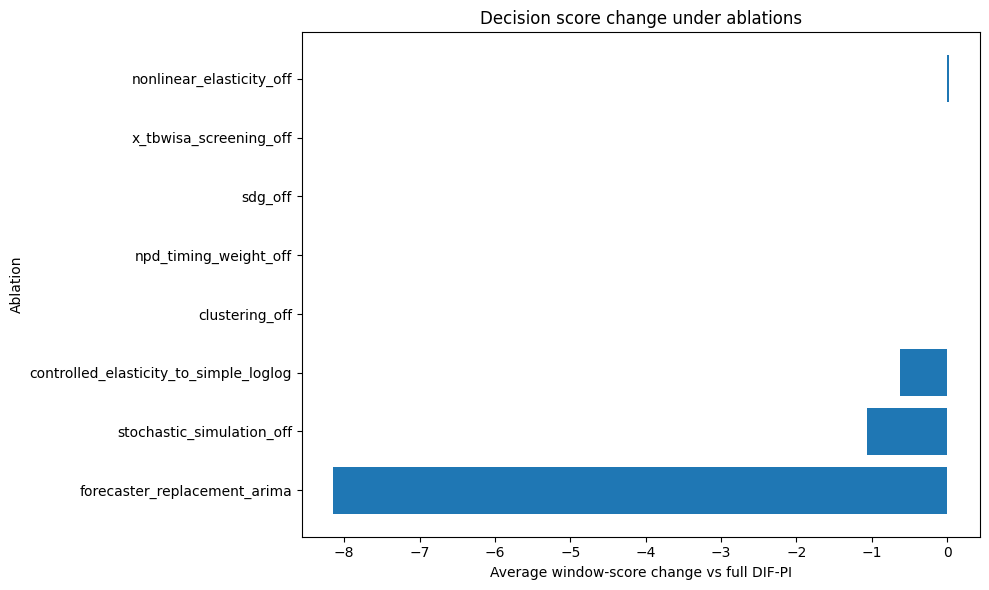

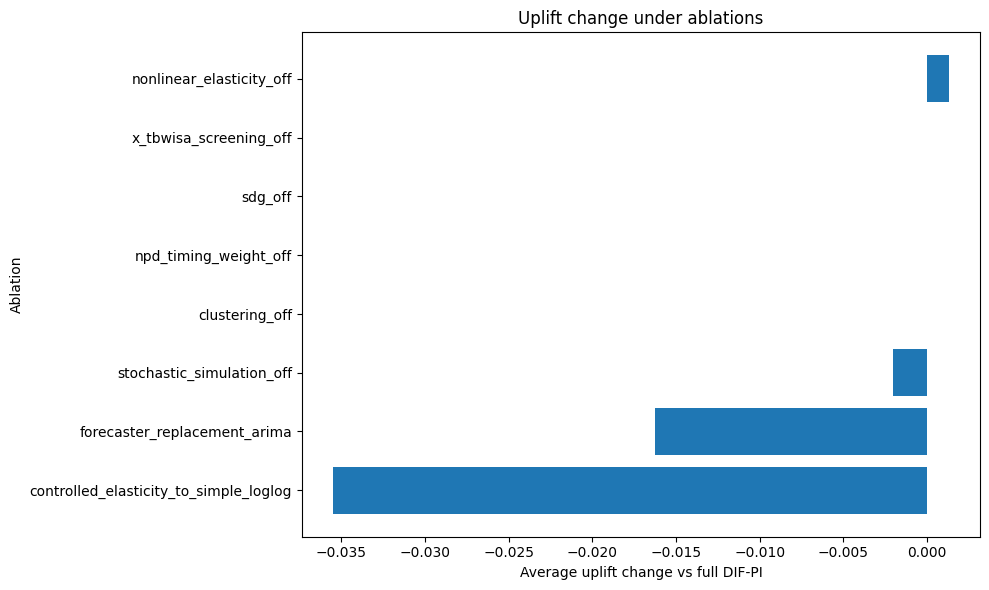

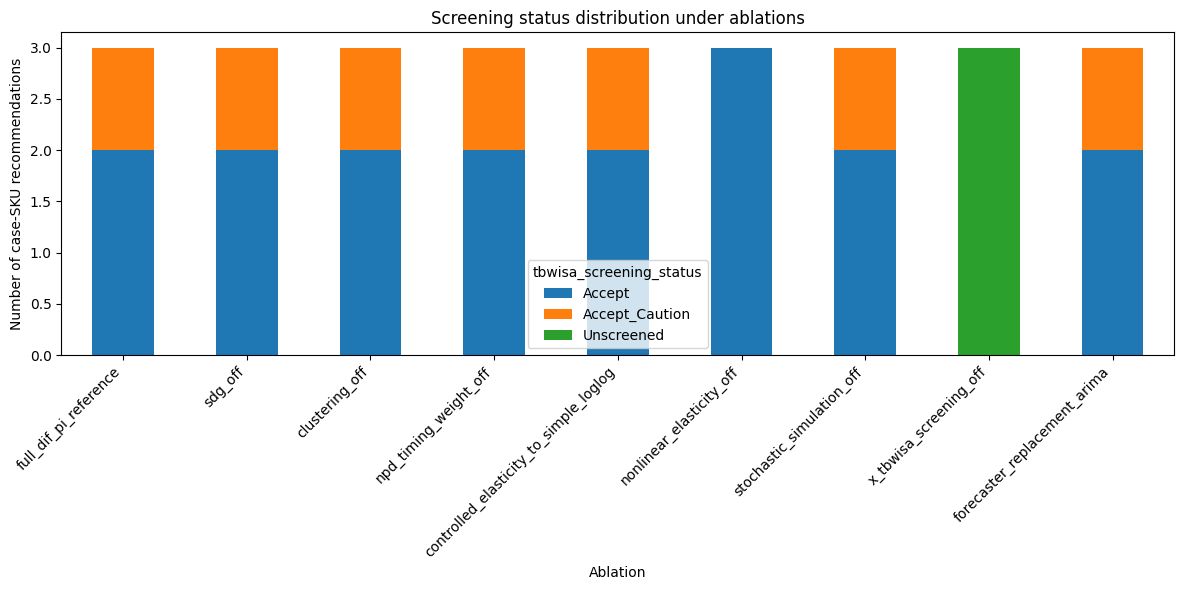

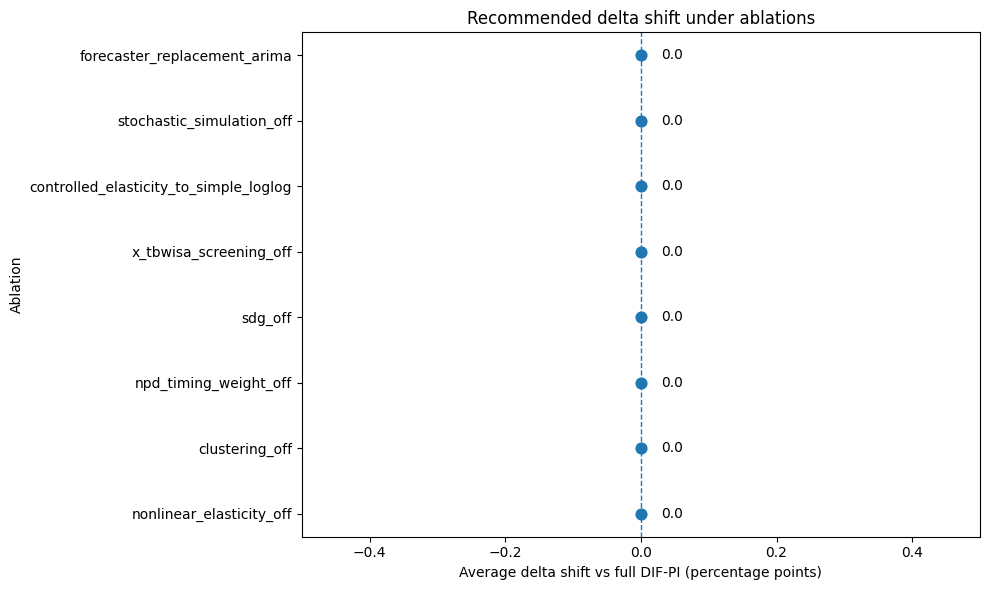

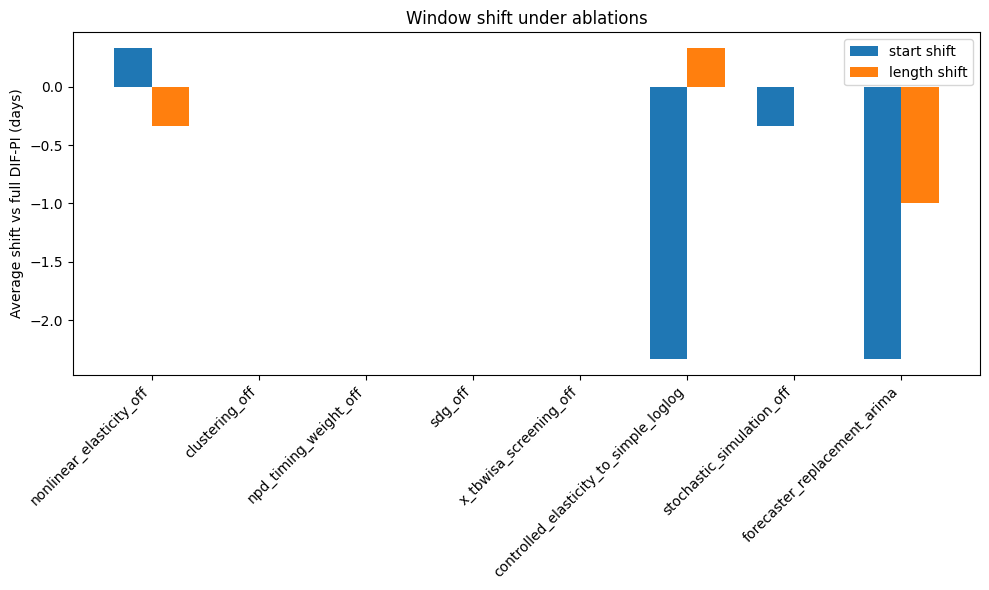

In [9]:
# Decision-score change under ablations
plot_df = ablation_summary[ablation_summary["ablation_name"] != "full_dif_pi_reference"].copy()
plot_df = plot_df.sort_values("avg_window_score_change_vs_full", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ablation_name"], plot_df["avg_window_score_change_vs_full"])
plt.xlabel("Average window-score change vs full DIF-PI")
plt.ylabel("Ablation")
plt.title("Decision score change under ablations")
plt.tight_layout()
plt.savefig(OUT_DIR / "decision_score_change_under_ablations.png", dpi=180, bbox_inches="tight")
plt.show()

# Uplift change under ablations
plot_df = ablation_summary[ablation_summary["ablation_name"] != "full_dif_pi_reference"].copy()
plot_df = plot_df.sort_values("avg_uplift_change_vs_full", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ablation_name"], plot_df["avg_uplift_change_vs_full"])
plt.xlabel("Average uplift change vs full DIF-PI")
plt.ylabel("Ablation")
plt.title("Uplift change under ablations")
plt.tight_layout()
plt.savefig(OUT_DIR / "uplift_change_under_ablations.png", dpi=180, bbox_inches="tight")
plt.show()

# Screening-status distribution under ablations
status_df = (
    ablation_case_level_results.groupby(["ablation_name", "tbwisa_screening_status"])
    .size()
    .reset_index(name="n")
)
status_pivot = status_df.pivot(index="ablation_name", columns="tbwisa_screening_status", values="n").fillna(0)
status_pivot = status_pivot.loc[[a["ablation_name"] for a in ABLATION_REGISTRY]]

status_pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.ylabel("Number of case-SKU recommendations")
plt.xlabel("Ablation")
plt.title("Screening status distribution under ablations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "screening_status_distribution_under_ablations.png", dpi=180, bbox_inches="tight")
plt.show()

# Recommended delta shift under ablations
plot_df = ablation_summary[ablation_summary["ablation_name"] != "full_dif_pi_reference"].copy()
plot_df = plot_df.sort_values("avg_delta_shift_vs_full", ascending=True)

vals = plot_df["avg_delta_shift_vs_full"].astype(float).values
plt.figure(figsize=(10, 6))
if np.allclose(vals, 0.0):
    y = np.arange(len(plot_df))
    plt.scatter(np.zeros(len(plot_df)), y, s=60)
    plt.yticks(y, plot_df["ablation_name"])
    plt.axvline(0, linestyle="--", linewidth=1)
    for yi in y:
        plt.text(0.03, yi, "0.0", va="center")
    plt.xlim(-0.5, 0.5)
else:
    plt.barh(plot_df["ablation_name"], plot_df["avg_delta_shift_vs_full"])
plt.xlabel("Average delta shift vs full DIF-PI (percentage points)")
plt.ylabel("Ablation")
plt.title("Recommended delta shift under ablations")
plt.tight_layout()
plt.savefig(OUT_DIR / "recommended_delta_shift_under_ablations.png", dpi=180, bbox_inches="tight")
plt.show()

# Window shift under ablations
plot_df = ablation_summary[ablation_summary["ablation_name"] != "full_dif_pi_reference"].copy().set_index("ablation_name")
plt.figure(figsize=(10, 6))
x = np.arange(len(plot_df))
w = 0.35
plt.bar(x - w/2, plot_df["avg_window_start_shift_vs_full"], width=w, label="start shift")
plt.bar(x + w/2, plot_df["avg_window_length_shift_vs_full"], width=w, label="length shift")
plt.xticks(x, plot_df.index, rotation=45, ha="right")
plt.ylabel("Average shift vs full DIF-PI (days)")
plt.title("Window shift under ablations")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "window_shift_under_ablations.png", dpi=180, bbox_inches="tight")
plt.show()

## 8) Export thesis-ready tables

In [10]:
ablation_case_level_results.to_csv(OUT_DIR / "ablation_case_level_results.csv", index=False)
ablation_summary.to_csv(OUT_DIR / "ablation_summary.csv", index=False)
tbwisa_mechanism_ablation_summary.to_csv(OUT_DIR / "tbwisa_mechanism_ablation_summary.csv", index=False)
managerial_ablation_summary.to_csv(OUT_DIR / "managerial_ablation_summary.csv", index=False)

print("Exported files:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)

Exported files:
- ablation_case_level_results.csv
- ablation_summary.csv
- average_forecast_revenue_vs_delta_across_case_skus.png
- average_forecast_revenue_vs_delta_case_sku_1070820.png
- average_forecast_revenue_vs_delta_case_sku_1082185.png
- average_forecast_revenue_vs_delta_case_sku_908531.png
- average_forecast_revenue_vs_delta_case_sku_9553031.png
- case_study_candidate_skus.csv
- case_study_selection_summary.csv
- cross_case_executive_recommendation_summary.png
- cumulative_revenue_with_selected_window_case_sku_1070820.png
- cumulative_revenue_with_selected_window_case_sku_1082185.png
- cumulative_revenue_with_selected_window_case_sku_908531.png
- cumulative_revenue_with_selected_window_case_sku_9553031.png
- decision_score_change_under_ablations.png
- decision_table_case_sku_1070820.csv
- decision_table_case_sku_1082185.csv
- decision_table_case_sku_1085604.csv
- decision_table_case_sku_1404121.csv
- decision_table_case_sku_397896.csv
- decision_table_case_sku_5569471.csv
- de

## 9) Display final tables

In [11]:
display(ablation_summary)
display(tbwisa_mechanism_ablation_summary)
display(managerial_ablation_summary)
display(ablation_case_level_results)

,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
0,nonlinear_elasticity_off,0.025252,0.001322,0.0,0.333333,-0.333333,1.0,-1.125445
1,clustering_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
2,full_dif_pi_reference,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
3,npd_timing_weight_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
4,sdg_off,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
5,x_tbwisa_screening_off,0.000000,0.000000,0.0,0.000000,0.000000,0.0,-1.125445
6,controlled_elasticity_to_simple_loglog,-0.624630,-0.035518,0.0,-2.333333,0.333333,1.0,-1.459009
7,stochastic_simulation_off,-1.061702,-0.002017,0.0,-0.333333,0.000000,1.0,-1.125445
8,forecaster_replacement_arima,-8.152809,-0.016258,0.0,-2.333333,-1.000000,1.0,-1.125445


,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
0,nonlinear_elasticity_off,0.025252,0.001322,0.0,0.333333,-0.333333,1.0,-1.125445
2,full_dif_pi_reference,0.000000,0.000000,0.0,0.000000,0.000000,1.0,-1.125445
6,controlled_elasticity_to_simple_loglog,-0.624630,-0.035518,0.0,-2.333333,0.333333,1.0,-1.459009
7,stochastic_simulation_off,-1.061702,-0.002017,0.0,-0.333333,0.000000,1.0,-1.125445
8,forecaster_replacement_arima,-8.152809,-0.016258,0.0,-2.333333,-1.000000,1.0,-1.125445


,ablation_name,avg_window_score_change_vs_full,avg_uplift_change_vs_full,avg_delta_shift_vs_full,avg_window_start_shift_vs_full,avg_window_length_shift_vs_full,accept_or_caution_rate,mean_beta_final
1,clustering_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
2,full_dif_pi_reference,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
3,npd_timing_weight_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
4,sdg_off,0.0,0.0,0.0,0.0,0.0,1.0,-1.125445
5,x_tbwisa_screening_off,0.0,0.0,0.0,0.0,0.0,0.0,-1.125445


,case_sku,ablation_name,decision_date,npd_mae,timing_alpha,tbwisa_recommended_delta_pct,tbwisa_window_start_offset_days,tbwisa_window_length_days,tbwisa_uplift_ratio,tbwisa_window_score,tbwisa_screening_status,tbwisa_screening_reason,elasticity_beta_raw,elasticity_beta_final
0,1082185,full_dif_pi_reference,2019-11-13,1.414887,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
1,9553031,full_dif_pi_reference,2019-11-13,1.414887,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
2,908531,full_dif_pi_reference,2019-11-13,1.414887,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
3,1082185,sdg_off,2019-11-13,1.414887,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
4,9553031,sdg_off,2019-11-13,1.414887,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
5,908531,sdg_off,2019-11-13,1.414887,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
6,1082185,clustering_off,2019-11-13,1.073508,0.3,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
7,9553031,clustering_off,2019-11-13,1.073508,0.3,15,22,7,0.150178,3.089218,Accept,ok,-0.042966,-0.042966
8,908531,clustering_off,2019-11-13,1.073508,0.3,-15,21,9,0.391927,26.302905,Accept,ok,-3.154960,-3.154960
9,1082185,npd_timing_weight_off,2019-11-13,NaN,0.0,15,22,8,0.144884,74.635483,Accept_Caution,local_warning,-0.178409,-0.178409
